# Import Libraries



In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, LSTM, Bidirectional, 
                                     Dense, Dropout, BatchNormalization, MultiHeadAttention, 
                                     GlobalAveragePooling1D, LayerNormalization, Add)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Load Data

In [123]:
df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_daily['datetime'] = pd.to_datetime(df_daily['datetime'])
df_daily = df_daily.sort_values('datetime')

# تحميل ملف الساعة
df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])
df_hourly = df_hourly.sort_values('datetime')

In [88]:
print("📊 Data Loaded Successfully. Shape:", df.shape)

📊 Data Loaded Successfully. Shape: (74836, 5)


In [89]:
print(f"🧹 Missing values before cleaning:\n{df.isnull().sum()}")
df.dropna(inplace=True)
df.sort_index(inplace=True)

🧹 Missing values before cleaning:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


# Data Exploration (EDA)


In [90]:
df.head()


,open,high,low,close,volume
datetime,,,,,
2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009
2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916
2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691
2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249
2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807


In [91]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 74836 entries, 2017-08-17 04:00:00 to 2026-03-06 15:00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    74836 non-null  float64
 1   high    74836 non-null  float64
 2   low     74836 non-null  float64
 3   close   74836 non-null  float64
 4   volume  74836 non-null  float64
dtypes: float64(5)
memory usage: 3.4 MB


In [92]:
df.describe()


,open,high,low,close,volume
count,74836.000000,74836.000000,74836.000000,74836.000000,74836.000000
mean,36851.016673,37001.564862,36692.820444,36851.874718,2574.760733
std,32398.816181,32497.076909,32296.889244,32398.813822,3891.364361
min,2870.900000,2950.000000,2817.000000,2919.000000,0.000000
25%,9211.495000,9246.992500,9174.075000,9211.905000,752.894197
50%,26771.575000,26845.780000,26691.845000,26772.635000,1395.532382
75%,57867.567500,58146.277500,57585.740000,57868.040000,2717.285290
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600


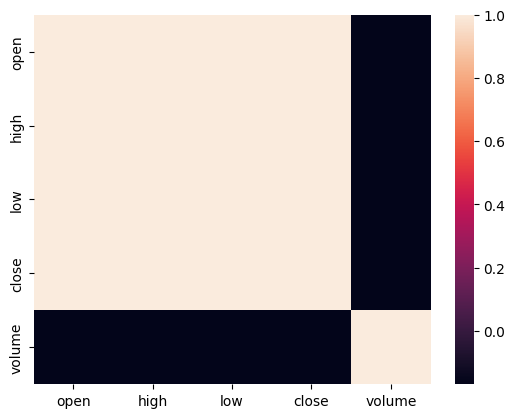

In [93]:
sns.heatmap(df.corr())
plt.show()

# Feature Engineering

In [94]:
print("Engineering 15 Professional Features (Manual Calculations)...")

Engineering 15 Professional Features (Manual Calculations)...


### EMA

In [95]:
df['EMA_10'] = df['close'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['close'].ewm(span=50, adjust=False).mean()

## Momentum Indicators

### 1. RSI (14)

In [96]:
delta = df['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / loss)))

### 2. MACD (12, 26, 9)

In [97]:
exp12 = df['close'].ewm(span=12, adjust=False).mean()
exp26 = df['close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp12 - exp26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

### 3. Stochastic %K (14)

In [98]:
low_14 = df['low'].rolling(window=14).min()
high_14 = df['high'].rolling(window=14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14))
df['Will_R'] = -100 * ((high_14 - df['close']) / (high_14 - low_14))

##  Volatility Indicators

### 1. ATR (Average True Range)

In [99]:
high_low = df['high'] - df['low']
high_pc = np.abs(df['high'] - df['close'].shift())
low_pc = np.abs(df['low'] - df['close'].shift())
tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
df['ATR'] = tr.rolling(window=14).mean()

### 2. Bollinger Bands (20, 2) & BB Width

In [100]:
ma20 = df['close'].rolling(window=20).mean()
std20 = df['close'].rolling(window=20).std()
df['BB_Width'] = (std20 * 4) / ma20

## Cycles & Strength 

### 1. CCI (20)

In [101]:
tp = (df['high'] + df['low'] + df['close']) / 3
ma_tp = tp.rolling(window=20).mean()
mad_tp = tp.rolling(window=20).apply(lambda x: np.abs(x - x.mean()).mean())
df['CCI'] = (tp - ma_tp) / (0.015 * mad_tp)

## Returns

In [102]:
cols_to_pct = ['open', 'high', 'low', 'close', 'volume', 'EMA_10', 'EMA_20', 'EMA_50', 'ATR']
for col in cols_to_pct:
    df[col + '_ret'] = df[col].pct_change()

## Target

In [103]:
df['Target'] = (df['close'].shift(-24) > df['close']).astype(int)

In [104]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

### test

In [105]:
df.describe()


,open,high,low,close,volume,EMA_10,EMA_20,EMA_50,RSI,MACD,...,open_ret,high_ret,low_ret,close_ret,volume_ret,EMA_10_ret,EMA_20_ret,EMA_50_ret,ATR_ret,Target
count,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,...,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000,74813.000000
mean,36860.099926,37010.676729,36701.869749,36860.956164,2575.379854,36857.019995,36852.571135,36839.213361,50.886943,6.245184,...,0.000068,0.000060,0.000070,0.000067,0.155786,0.000040,0.000038,0.000038,0.002254,0.520284
std,32399.242186,32497.498599,32297.318552,32399.241479,3891.665299,32396.432938,32393.607577,32385.458176,16.425611,299.220642,...,0.007824,0.006920,0.008053,0.007821,1.217032,0.002319,0.001629,0.001024,0.068748,0.499592
min,2870.900000,2950.000000,2817.000000,2919.000000,0.000000,3107.464635,3208.311460,3245.719244,0.547546,-2527.269181,...,-0.182201,-0.129828,-0.243869,-0.182115,-1.000000,-0.047895,-0.030895,-0.015680,-0.450443,0.000000
25%,9214.010000,9248.790000,9176.450000,9214.910000,753.337100,9211.639280,9209.998696,9214.189308,39.514754,-68.703636,...,-0.002473,-0.002261,-0.002067,-0.002480,-0.269560,-0.000733,-0.000551,-0.000384,-0.029974,0.000000
50%,26779.450000,26848.070000,26702.630000,26779.790000,1395.793020,26801.605751,26795.211590,26778.609781,50.743969,3.813888,...,0.000078,-0.000205,0.000352,0.000074,-0.033560,0.000060,0.000047,0.000038,-0.000472,1.000000
75%,57877.970000,58150.000000,57599.570000,57877.970000,2717.847393,57831.722011,57854.979458,57773.696532,62.233130,87.355636,...,0.002655,0.002067,0.002657,0.002672,0.310889,0.000867,0.000670,0.000493,0.028641,1.000000
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,125062.361818,124694.100415,124031.476731,100.000000,2390.735922,...,0.173670,0.152525,0.271352,0.173840,190.760354,0.033865,0.020696,0.010494,1.701271,1.000000


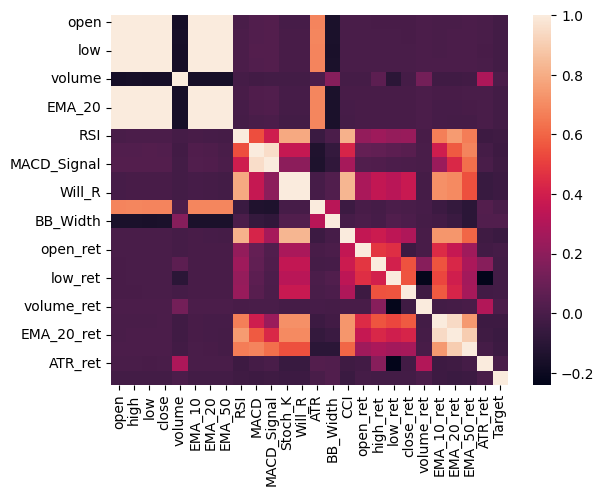

In [106]:
sns.heatmap(df.corr())
plt.show()

## remove the bad cloumne  

In [107]:
df = df.drop("open", axis=1)
df = df.drop("low", axis=1)
df = df.drop("high", axis=1)
df = df.drop("close", axis=1)
# df = df.drop("BB_Upper", axis=1)
df = df.drop("EMA_50", axis=1)
df = df.drop("EMA_10", axis=1)
df = df.drop("EMA_20", axis=1)


In [108]:
df = df.drop(["BB_Lower", "ATR"], axis=1, errors='ignore')

final_features = [
    'close_ret', 'volume_ret', 'open_ret', 'ATR_ret', 'EMA_10_ret',
    'RSI', 'MACD', 'MACD_Signal', 'Stoch_K', 'Will_R',
    'BB_Width', 'CCI', 'high_ret' 
]

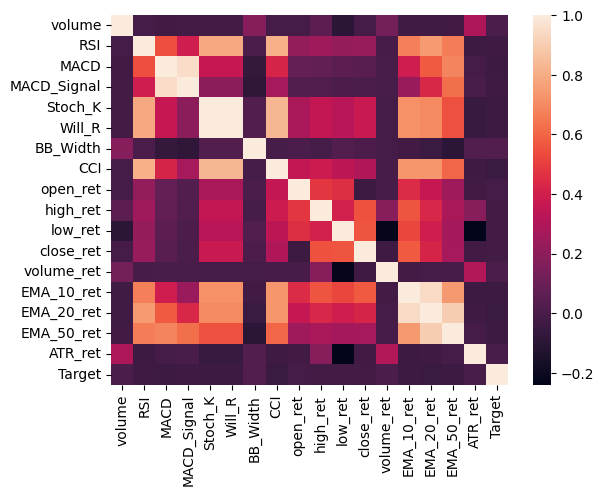

In [109]:
sns.heatmap(df.corr())
plt.show()

# Data Scaling

In [110]:
X_data = df[final_features].values
y_data = df['Target'].values

In [111]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)

In [112]:
joblib.dump(scaler, "egx360_scaler.pkl")
print("Data Scaled and Scaler saved.")

Data Scaled and Scaler saved.


# Train / Test Split

In [113]:
split_idx = int(len(X_scaled) * 0.8)

In [114]:
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]

In [115]:
print(f"📅 Training records: {len(train_data)} | Testing records: {len(test_data)}")

📅 Training records: 59850 | Testing records: 14963


# Create Sequences

In [116]:
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 22

In [117]:
X_train, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test, y_test = create_sequences(test_data, test_target, SEQ_LEN)
print(f"📦 X_train shape: {X_train.shape}") # (Samples, Time Steps, Features)


📦 X_train shape: (59828, 22, 13)


# Build Model

In [118]:
def build_advanced_egx360(input_shape):
    inputs = Input(shape=input_shape)
    
    # [A] CNN Layer
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x) 
    
    # [B] Bidirectional LSTM
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = LayerNormalization()(x) 
    
    # [C] Multi-Head Attention
    attention_out = MultiHeadAttention(num_heads=4, key_dim=128)(x, x)
    x = Add()([x, attention_out]) 
    
    # [D] Final Dense Layers
    x = GlobalAveragePooling1D()(x) 
    x = Dense(64, activation='swish')(x) 
    x = Dropout(0.4)(x)
    
    outputs = Dense(1, activation='sigmoid')(x)
    
    return Model(inputs=inputs, outputs=outputs)

model = build_advanced_egx360((X_train.shape[1], X_train.shape[2]))
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 22, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 22, 64)    │      2,560 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 22, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 11, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 11, 256)   │    197,632 │ max_pooling1d_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 11, 256)   │        512 │ bidirectional_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 11, 256)   │    526,080 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 11, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ add_2[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     16,448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 743,553 (2.84 MB)

 Trainable params: 743,425 (2.84 MB)

 Non-trainable params: 128 (512.00 B)

# Train Model

In [119]:
print("⚖️ Calculating Class Weights...")
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict = {i: weights[i] for i in range(len(weights))}

⚖️ Calculating Class Weights...


In [120]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
checkpoint = ModelCheckpoint("EGX360_Pro_Model.keras", monitor='val_accuracy', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

In [121]:
print("🚀 Starting Pro Training Process...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150, 
    batch_size=32,
    class_weight=cw_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

🚀 Starting Pro Training Process...
Epoch 1/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 92s 47ms/step - accuracy: 0.5188 - loss: 0.7018 - val_accuracy: 0.5120 - val_loss: 0.6997 - learning_rate: 1.0000e-04
Epoch 2/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.5276 - loss: 0.6942 - val_accuracy: 0.5004 - val_loss: 0.7045 - learning_rate: 1.0000e-04
Epoch 3/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.5398 - loss: 0.6889 - val_accuracy: 0.5154 - val_loss: 0.6942 - learning_rate: 1.0000e-04
Epoch 4/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.5514 - loss: 0.6834 - val_accuracy: 0.4905 - val_loss: 0.7072 - learning_rate: 1.0000e-04
Epoch 5/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.5576 - loss: 0.6804 - val_accuracy: 0.5168 - val_loss: 0.6989 - learning_rate: 1.0000e-04
Epoch 6/150
1870/1870 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.5693 - loss: 0.6747 - val_accuracy: 0.5053 - val_loss: 0.7134 - learning_rate: 1.0000e-04

KeyboardInterrupt: 

# Evaluate Model


📊 Evaluating Performance on Test Data...
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
✅ Optimal Threshold found: 0.10

🔥 Final Classification Report:
              precision    recall  f1-score   support

        Down       0.50      0.45      0.47      7297
          Up       0.52      0.58      0.55      7644

    accuracy                           0.51     14941
   macro avg       0.51      0.51      0.51     14941
weighted avg       0.51      0.51      0.51     14941



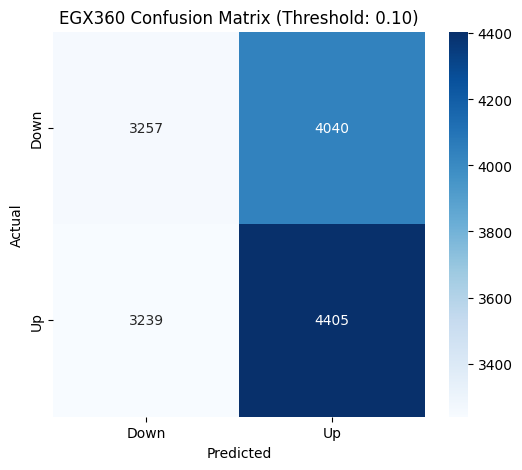

In [122]:
print("\n📊 Evaluating Performance on Test Data...")
y_probs = model.predict(X_test)

# Dynamic Thresholding for best F1-Score
thresholds = np.arange(0.1, 0.9, 0.01)
scores = [f1_score(y_test, (y_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]
print(f'✅ Optimal Threshold found: {best_threshold:.2f}')

final_preds = (y_probs > 0.50).astype(int)

print("\n🔥 Final Classification Report:")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 Confusion Matrix (Threshold: {best_threshold:.2f})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

2026-03-06 21:54:18.376551: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-06 21:54:18.380216: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 21:54:18.697932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 21:54:20.932779: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

📥 Loading Data & Engineering Features...
🔗 Performing Triple Fusion...
📦 DL Shape: (56577, 72, 11) | XGBoost Shape: (56577, 792)

🧠 Training Model A: Time-Series Transformer...


E0000 00:00:1772826862.438370   18355 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772826862.445338   18355 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.5120 - loss: 0.7059 - val_accuracy: 0.4961 - val_loss: 0.6973 - learning_rate: 1.0000e-04
Epoch 2/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.5213 - loss: 0.6931 - val_accuracy: 0.5015 - val_loss: 0.6965 - learning_rate: 1.0000e-04
Epoch 3/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.5204 - loss: 0.6922 - val_accuracy: 0.5105 - val_loss: 0.6936 - learning_rate: 1.0000e-04
Epoch 4/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.5222 - loss: 0.6916 - val_accuracy: 0.5286 - val_loss: 0.6923 - learning_rate: 1.0000e-04
Epoch 5/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.5242 - loss: 0.6909 - val_accuracy: 0.5178 - val_loss: 0.6930 - learning_rate: 1.0000e-04
Epoch 6/100
1769/1769 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.5263 - loss: 0.6907 - val_accuracy: 0.5044 - val_loss: 0.6941 - learning_rate: 1.0000e-04
Epoch 7/100
1769/1769 ━━━━━━━━━━━━

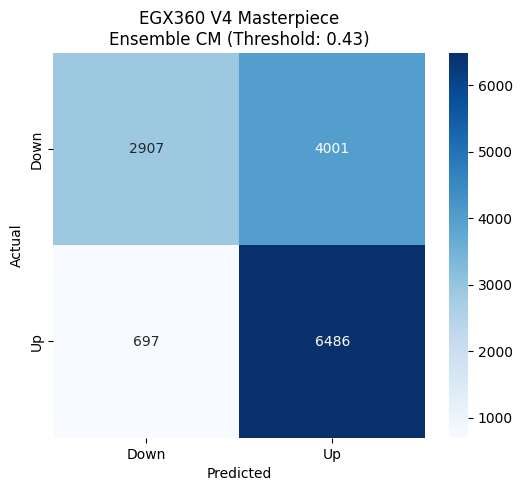

In [3]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pywt  
import xgboost as xgb  # الوحش الجديد
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, LayerNormalization, 
                                     MultiHeadAttention, GlobalAveragePooling1D, Add)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ==========================================
# 2. DWT Noise Filter (نفس الفلتر الناجح بتاعنا)
# ==========================================
def apply_dwt_denoising(signal):
    signal = np.array(signal, copy=True)
    coeffs = pywt.wavedec(signal, 'db4', level=2)
    coeffs[-1] = np.zeros_like(coeffs[-1])
    denoised = pywt.waverec(coeffs, 'db4')
    return denoised[:len(signal)]

# ==========================================
# 3. Load Data & 4. Feature Engineering
# ==========================================
print("📥 Loading Data & Engineering Features...")
df_daily = pd.read_csv("data/BTC_all_daily.csv")
df_daily['datetime'] = pd.to_datetime(df_daily['datetime'])

df_hourly = pd.read_csv("data/BTC_ALL_HOURLY.csv")
df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

df_fng = pd.read_csv("data/Fear_Greed_Daily.csv") 
df_fng['datetime'] = pd.to_datetime(df_fng['datetime'])

df_daily.sort_values('datetime', inplace=True)
df_hourly.sort_values('datetime', inplace=True)
df_fng.sort_values('datetime', inplace=True)

def calculate_advanced_features(df, prefix):
    df = df.copy()
    df['close_denoised'] = apply_dwt_denoising(df['close'].values)
    df[f'EMA_10_{prefix}'] = df['close_denoised'].ewm(span=10, adjust=False).mean()
    
    delta = df['close_denoised'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    df[f'RSI_{prefix}'] = 100 - (100 / (1 + (gain / loss)))
    
    exp12 = df['close_denoised'].ewm(span=12, adjust=False).mean()
    exp26 = df['close_denoised'].ewm(span=26, adjust=False).mean()
    df[f'MACD_{prefix}'] = exp12 - exp26
    
    ma20 = df['close_denoised'].rolling(window=20).mean()
    std20 = df['close_denoised'].rolling(window=20).std()
    df[f'BB_Width_{prefix}'] = (std20 * 4) / ma20
    
    df[f'close_ret_{prefix}'] = df['close'].pct_change()
    df[f'volume_ret_{prefix}'] = df['volume'].pct_change()
    return df.dropna()

df_daily = calculate_advanced_features(df_daily, "daily")
df_hourly = calculate_advanced_features(df_hourly, "hourly")

daily_cols = ['datetime', 'RSI_daily', 'MACD_daily', 'BB_Width_daily', 'close_ret_daily']
df_daily = df_daily[daily_cols]

# ==========================================
# 5. Data Fusion & 6. Scaling
# ==========================================
print("🔗 Performing Triple Fusion...")
df_merged = pd.merge_asof(df_hourly, df_daily, on='datetime', direction='backward')
df_merged = pd.merge_asof(df_merged, df_fng, on='datetime', direction='backward')

df_merged['Target'] = (df_merged['close'].shift(-24) > df_merged['close']).astype(int)
df_merged.replace([np.inf, -np.inf], np.nan, inplace=True)
df_merged.dropna(inplace=True)

final_features = [
    'close_ret_hourly', 'volume_ret_hourly', 'EMA_10_hourly', 'RSI_hourly', 'MACD_hourly', 'BB_Width_hourly', 
    'close_ret_daily', 'RSI_daily', 'MACD_daily', 'BB_Width_daily', 'Fear_Greed_Index'  
]

X_data = df_merged[final_features].values
y_data = df_merged['Target'].values

scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X_data)
joblib.dump(scaler, "egx360_scaler_v4.pkl")

split_idx = int(len(X_scaled) * 0.8)
train_data, test_data = X_scaled[:split_idx], X_scaled[split_idx:]
train_target, test_target = y_data[:split_idx], y_data[split_idx:]

# ==========================================
# 7. Create Sequences (For DL) & Flattening (For XGBoost)
# ==========================================
def create_sequences(data, target, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : (i + seq_len)])
        ys.append(target[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 72 
X_train_dl, y_train = create_sequences(train_data, train_target, SEQ_LEN)
X_test_dl, y_test = create_sequences(test_data, test_target, SEQ_LEN)

# XGBoost بيحتاج داتا مسطحة (2D) بدل (3D)، فهنضرب 72 ساعة في 11 ميزة
X_train_xgb = X_train_dl.reshape((X_train_dl.shape[0], -1))
X_test_xgb = X_test_dl.reshape((X_test_dl.shape[0], -1))

print(f"📦 DL Shape: {X_train_dl.shape} | XGBoost Shape: {X_train_xgb.shape}")

# ==========================================
# 8. Model A: Time-Series Transformer
# ==========================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Self-Attention
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    res = Add()([x, inputs])
    x = LayerNormalization(epsilon=1e-6)(res)
    # Feed Forward
    x = Dense(ff_dim, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    res = Add()([x, res])
    return LayerNormalization(epsilon=1e-6)(res)

def build_transformer(input_shape):
    inputs = Input(shape=input_shape)
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.3)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)

print("\n🧠 Training Model A: Time-Series Transformer...")
transformer_model = build_transformer((X_train_dl.shape[1], X_train_dl.shape[2]))
transformer_model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.00001)

transformer_model.fit(
    X_train_dl, y_train,
    validation_data=(X_test_dl, y_test),
    epochs=100, batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
transformer_model.save("EGX360_Transformer.keras")

# ==========================================
# 9. Model B: XGBoost Classifier
# ==========================================
print("\n🌲 Training Model B: XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=42
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=50
)
joblib.dump(xgb_model, "EGX360_XGBoost.pkl")

# ==========================================
# 10. Ensemble Learning (Soft Voting)
# ==========================================
print("\n🤝 Performing Ensemble (Transformer + XGBoost)...")
# استخراج الاحتمالات من الموديلين
dl_probs = transformer_model.predict(X_test_dl).flatten()
xgb_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]

# حساب المتوسط (Soft Voting)
final_probs = (dl_probs + xgb_probs) / 2.0

# البحث عن أفضل Threshold ديناميكياً بناءً على الـ Ensemble
thresholds = np.arange(0.1, 0.9, 0.01)
scores = [f1_score(y_test, (final_probs > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(scores)]
print(f'✅ Optimal Ensemble Threshold found: {best_threshold:.2f}')

final_preds = (final_probs > best_threshold).astype(int)

# ==========================================
# 11. Final Evaluation
# ==========================================
print("\n🔥 Final Classification Report (Ensemble V4):")
print(classification_report(y_test, final_preds, target_names=['Down', 'Up']))

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title(f"EGX360 V4 Masterpiece\nEnsemble CM (Threshold: {best_threshold:.2f})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()